# Exploratory Data Analysis — Sales Performance

The objective of Exploratory Data Analysis (EDA) is to understand the
overall structure, patterns, trends, and relationships within the
cleaned retail transaction data before conducting deeper customer
and segmentation analysis.

The EDA focuses on:

- Understanding overall sales and transaction performance
- Identifying revenue and transaction trends over time
- Evaluating product-level sales and quantity performance
- Comparing sales performance across countries
- Understanding transaction value and purchasing patterns
- Identifying high-performing products and markets
- Measuring sales and customer concentration

EDA will answer the question:

"How is the business performing, where are sales coming from, and
what patterns in the transaction data require further investigation?"

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [3]:
# Load the processed data
PROJECT_DIR = Path.cwd().parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

sales_file = PROCESSED_DIR / "retail_sales_cleaned.csv"

sales_df = pd.read_csv(sales_file, parse_dates=["InvoiceDate"])

print(f"Dataset loaded: {sales_df.shape}")

C:\Users\tanya\AppData\Local\Temp\ipykernel_16332\3290194670.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv(sales_file, parse_dates=["InvoiceDate"])


Dataset loaded: (524878, 10)


In [4]:
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False


```
1 customer
      ↓
makes 1 purchase/order
      ↓
gets 1 invoice
      ↓
buys several different products
      ↓
each product becomes a row
```

In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
 8   Sales        524878 non-null  float64       
 9   IsCancelled  524878 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 36.5+ MB


In [6]:
sales_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Sales
count,524878.000000,524878,524878.000000,392692.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,1713.539549,271.693566


In [7]:
# Establish the KPI baseline
total_revenue = sales_df["Sales"].sum()

total_units = sales_df["Quantity"].sum()

total_transactions = sales_df["InvoiceNo"].nunique()

total_customers = sales_df["CustomerID"].nunique()

average_transaction_value = sales_df.groupby("InvoiceNo")["Sales"].sum().mean()

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,.0f}")
print(f"Total Transactions: {total_transactions:,.0f}")
print(f"Unique Customers: {total_customers:,.0f}")
print(f"Average Transaction Value: {average_transaction_value:,.2f}")

Total Revenue: 10,642,110.80
Total Units Sold: 5,572,420
Total Transactions: 19,962
Unique Customers: 4,338
Average Transaction Value: 533.12


In [8]:
# Revenue distribution
transaction_sales = sales_df.groupby("InvoiceNo")["Sales"].sum()
transaction_sales.describe()

count     19962.000000
mean        533.118465
std        1780.304163
min           0.380000
25%         151.710000
50%         303.300000
75%         493.450000
max      168469.600000
Name: Sales, dtype: float64

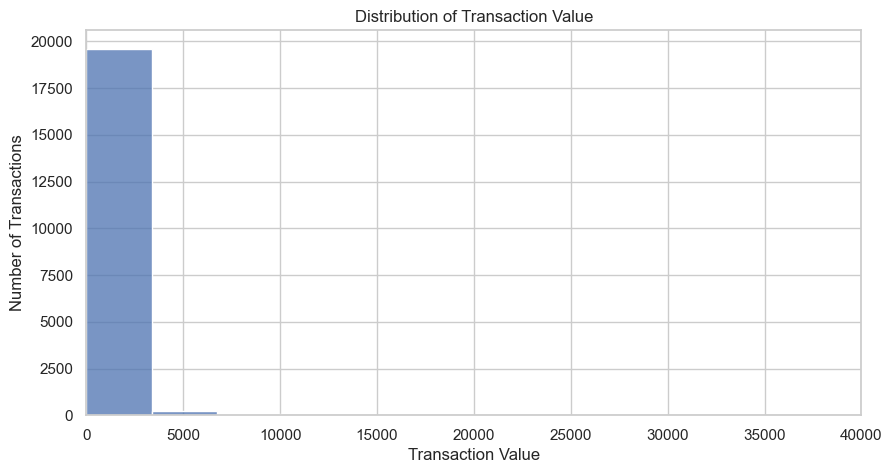

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(transaction_sales, bins=50)
plt.xlim(0,40000)

plt.title("Distribution of Transaction Value")
plt.xlabel("Transaction Value")
plt.ylabel("Number of Transactions")

plt.show()

This tells us whether transaction values are:

- concentrated around a typical value
- heavily skewed
- affected by very large orders

In [10]:
# Monthly revenue
monthly_sales = sales_df.set_index("InvoiceDate").resample("ME")["Sales"].sum()
monthly_sales

InvoiceDate
2010-12-31     821452.730
2011-01-31     689811.610
2011-02-28     522545.560
2011-03-31     716215.260
2011-04-30     536968.491
2011-05-31     769296.610
2011-06-30     760547.010
2011-07-31     718076.121
2011-08-31     757841.380
2011-09-30    1056435.192
2011-10-31    1151263.730
2011-11-30    1503866.780
2011-12-31     637790.330
Freq: ME, Name: Sales, dtype: float64

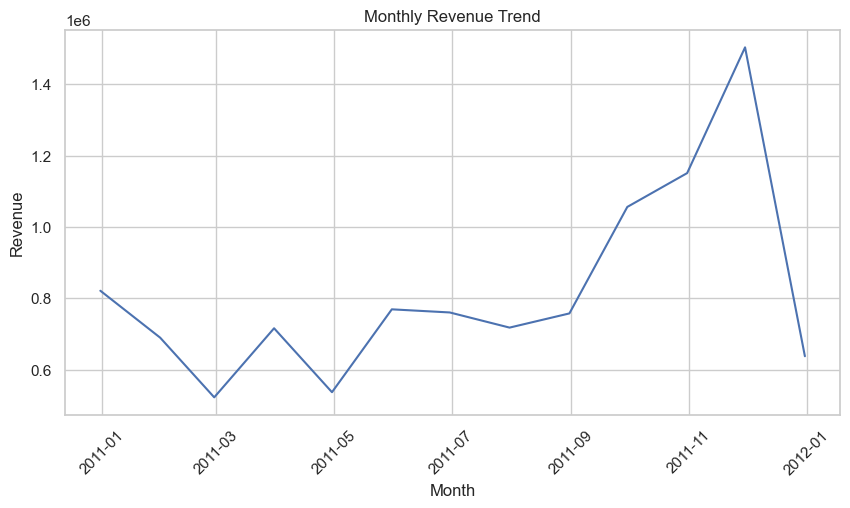

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

There is also a very sharp decline in the final period.

- We should not immediately conclude that sales collapsed.

We need to investigate:

- Is the last period a genuine decline, or is it a partial month?

```Revenue = Number of Transactions × Average Transaction Value```

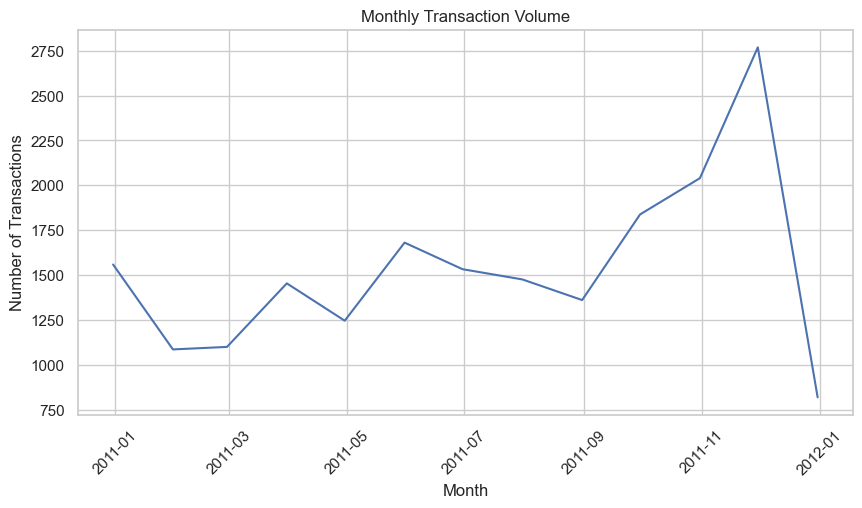

In [12]:
# Monthly transaction volume
monthly_transactions = sales_df.set_index("InvoiceDate").resample("ME")["InvoiceNo"].nunique()

plt.figure(figsize=(10, 5))

plt.plot(monthly_transactions.index, monthly_transactions.values)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

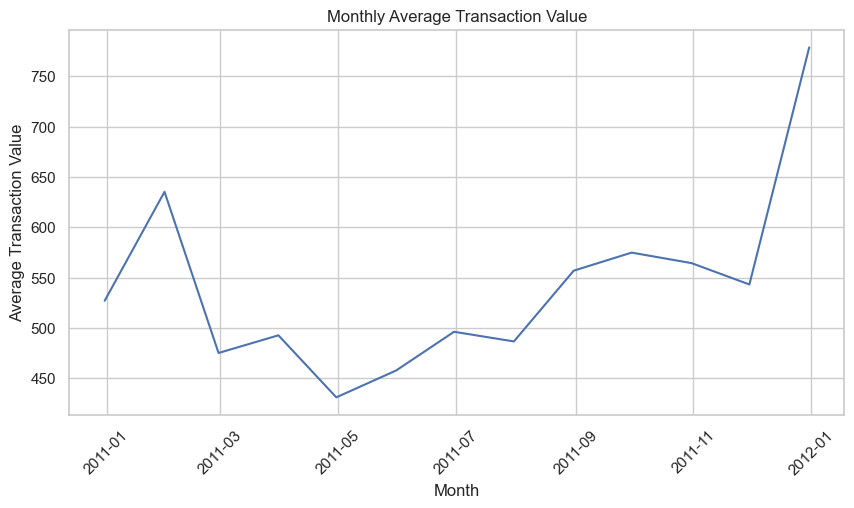

In [13]:
# Monthly average transaction value
monthly_atv = monthly_sales / monthly_transactions

plt.figure(figsize=(10, 5))

plt.plot(monthly_atv.index, monthly_atv.values)

plt.title("Monthly Average Transaction Value")
plt.xlabel("Month")
plt.ylabel("Average Transaction Value")

plt.xticks(rotation=45)

plt.show()

In [14]:
# Product Performance
product_revenue = sales_df.groupby(["StockCode", "Description"], dropna=False)["Sales"].sum().sort_values(ascending=False)
print("Top 10 products by revenue")
product_revenue.head(10)

Top 10 products by revenue


StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POST       POSTAGE                                78101.88
M          Manual                                 77750.27
23084      RABBIT NIGHT LIGHT                     66870.03
Name: Sales, dtype: float64

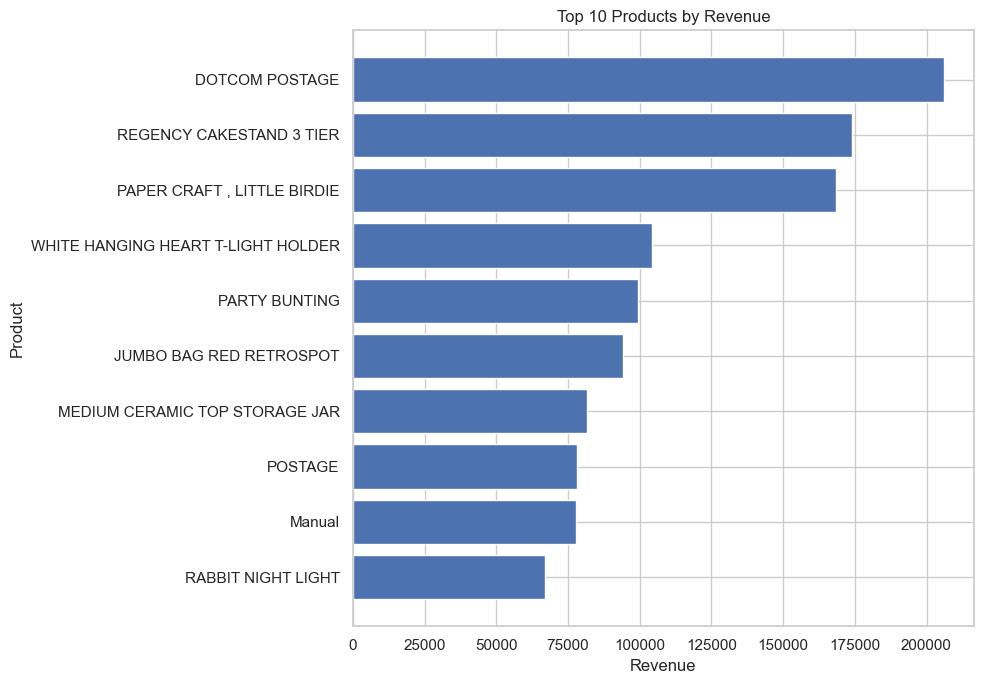

In [15]:
top_products = product_revenue.head(10).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(top_products.index.get_level_values("Description"), top_products.values)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [16]:
product_quantity = sales_df.groupby(["StockCode", "Description"])["Quantity"].sum().sort_values(ascending=False)
print("Top products by quantity")
product_quantity.head(10)

Top products by quantity


StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        78033
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
85099B     JUMBO BAG RED RETROSPOT               48371
85123A     WHITE HANGING HEART T-LIGHT HOLDER    37580
22197      POPCORN HOLDER                        36749
21212      PACK OF 72 RETROSPOT CAKE CASES       36396
84879      ASSORTED COLOUR BIRD ORNAMENT         36362
23084      RABBIT NIGHT LIGHT                    30739
22492      MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

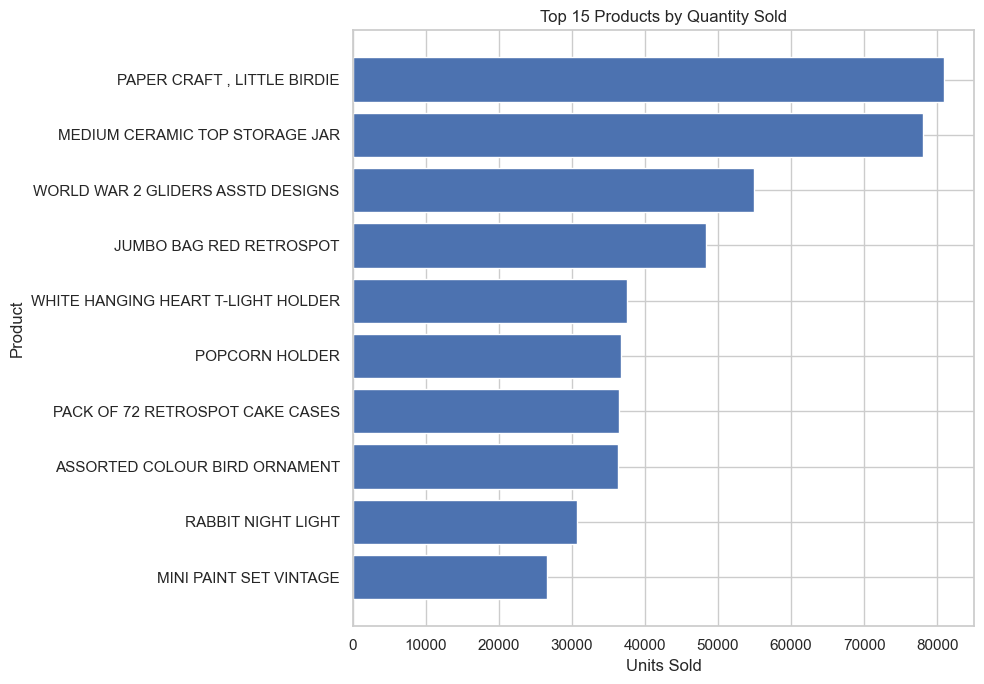

In [17]:
top_quantity = product_quantity.head(10).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(top_quantity.index.get_level_values("Description"), top_quantity.values)

plt.title("Top 15 Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [18]:
# Product transaction frequency
product_transactions = sales_df.groupby(["StockCode", "Description"])["InvoiceNo"].nunique().sort_values(ascending=False)
product_transactions.head(10)

StockCode  Description                       
85123A     WHITE HANGING HEART T-LIGHT HOLDER    2189
85099B     JUMBO BAG RED RETROSPOT               2089
22423      REGENCY CAKESTAND 3 TIER              1988
47566      PARTY BUNTING                         1685
20725      LUNCH BAG RED RETROSPOT               1564
84879      ASSORTED COLOUR BIRD ORNAMENT         1455
22720      SET OF 3 CAKE TINS PANTRY DESIGN      1385
21212      PACK OF 72 RETROSPOT CAKE CASES       1320
20727      LUNCH BAG  BLACK SKULL.               1273
22457      NATURAL SLATE HEART CHALKBOARD        1249
Name: InvoiceNo, dtype: int64

In [19]:
# Product-level summary table
# How concentrated is the company's revenue among its products?
product_summary = (sales_df.groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Sales", "sum"),
        Units_Sold=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Average_Unit_Price=("UnitPrice", "mean")
    )
    .sort_values("Revenue", ascending=False))

product_summary.head(10)

,,Revenue,Units_Sold,Transactions,Average_Unit_Price
StockCode,Description,,,,
DOT,DOTCOM POSTAGE,206248.77,706,706,292.137068
22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988,13.983936
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189,3.116159
47566,PARTY BUNTING,99445.23,18283,1685,5.797928
85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089,2.486197
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,1.468480
POST,POSTAGE,78101.88,3150,1126,31.076581
M,Manual,77750.27,6984,289,234.489652


In [20]:
# Revenue concentration
product_summary["Revenue_Share"] = (product_summary["Revenue"] / product_summary["Revenue"].sum())
product_summary["Cumulative_Revenue_Share"] = (product_summary["Revenue_Share"].cumsum())
product_summary.head(10)

,,Revenue,Units_Sold,Transactions,Average_Unit_Price,Revenue_Share,Cumulative_Revenue_Share
StockCode,Description,,,,,,
DOT,DOTCOM POSTAGE,206248.77,706,706,292.137068,0.019380,0.019380
22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988,13.983936,0.016365,0.035745
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000,0.015830,0.051576
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189,3.116159,0.009799,0.061375
47566,PARTY BUNTING,99445.23,18283,1685,5.797928,0.009345,0.070719
85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089,2.486197,0.008848,0.079567
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,1.468480,0.007677,0.087244
POST,POSTAGE,78101.88,3150,1126,31.076581,0.007339,0.094583
M,Manual,77750.27,6984,289,234.489652,0.007306,0.101889


In [21]:
top_10_share = (product_summary.head(10)["Revenue"].sum() / product_summary["Revenue"].sum())
top_20_share = (product_summary.head(20)["Revenue"].sum() / product_summary["Revenue"].sum())
top_50_share = (product_summary.head(50)["Revenue"].sum() / product_summary["Revenue"].sum())

print(f"Top 10 products revenue share: {top_10_share:.2%}")
print(f"Top 20 products revenue share: {top_20_share:.2%}")
print(f"Top 50 products revenue share: {top_50_share:.2%}")

Top 10 products revenue share: 10.82%
Top 20 products revenue share: 15.11%
Top 50 products revenue share: 23.48%


In [22]:
# Country Analysis
country_summary = (sales_df.groupby("Country")
    .agg(
        Revenue=("Sales", "sum"),
        Units=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values("Revenue", ascending=False))

country_summary.head(10)

,Revenue,Units,Transactions,Customers
Country,,,,
United Kingdom,9001744.094,4646906,18020,3920
Netherlands,285446.340,200361,94,9
EIRE,283140.520,147007,288,3
Germany,228678.400,119154,458,94
France,209625.370,112060,392,87
Australia,138453.810,83891,57,9
Spain,61558.560,27933,90,30
Switzerland,57067.600,30617,54,21
Belgium,41196.340,23237,98,25


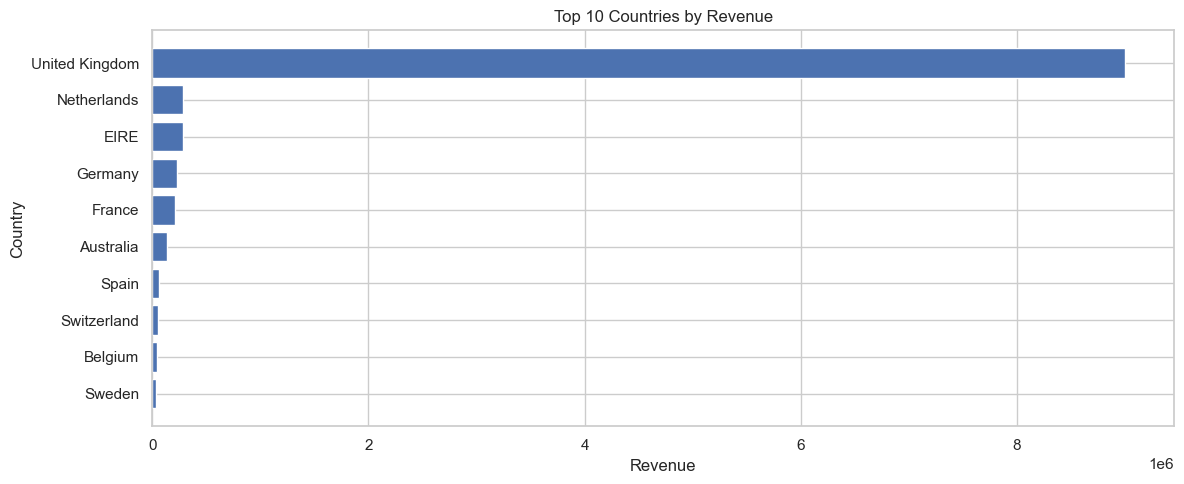

In [23]:
# Top countries by revenue
top_countries = country_summary.head(10).sort_values("Revenue")

plt.figure(figsize=(12, 5))

plt.barh(top_countries.index, top_countries["Revenue"])

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

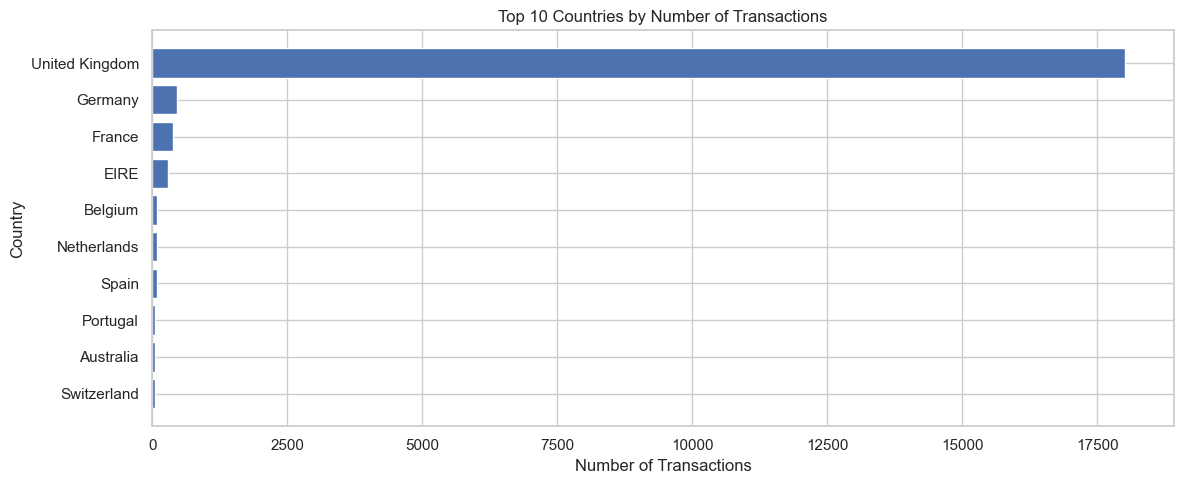

In [24]:
# Country transaction volume
top_country_transactions = (
    country_summary
    .sort_values("Transactions", ascending=False)
    .head(10)
    .sort_values("Transactions")
)

plt.figure(figsize=(12, 5))

plt.barh(top_country_transactions.index, top_country_transactions["Transactions"])

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [25]:
# Revenue per transaction
country_summary["Revenue_per_Transaction"] = np.round(
    country_summary["Revenue"]
    / country_summary["Transactions"]
,2)

country_summary.sort_values(
    "Revenue_per_Transaction",
    ascending=False
).head(10)

,Revenue,Units,Transactions,Customers,Revenue_per_Transaction
Country,,,,,
Singapore,21279.29,5241,7,1,3039.90
Netherlands,285446.34,200361,94,9,3036.66
Australia,138453.81,83891,57,9,2429.01
Japan,37416.37,26016,19,8,1969.28
Lebanon,1693.88,386,1,1,1693.88
Hong Kong,15483.00,4713,11,0,1407.55
Brazil,1143.60,356,1,1,1143.60
Sweden,38367.83,36078,36,8,1065.77
Switzerland,57067.60,30617,54,21,1056.81


In [26]:
# Revenue per customer
country_summary["Revenue_per_Customer"] = np.round(
    country_summary["Revenue"]
    / country_summary["Customers"]
,2)

# Introduce a minimum customer threshold
country_summary[country_summary['Customers'] >= 20
].sort_values(
    "Revenue_per_Customer",
    ascending=False
).head(10)

,Revenue,Units,Transactions,Customers,Revenue_per_Transaction,Revenue_per_Customer
Country,,,,,,
Switzerland,57067.600,30617,54,21,1056.81,2717.50
Germany,228678.400,119154,458,94,499.30,2432.75
France,209625.370,112060,392,87,534.76,2409.49
United Kingdom,9001744.094,4646906,18020,3920,499.54,2296.36
Spain,61558.560,27933,90,30,683.98,2051.95
Belgium,41196.340,23237,98,25,420.37,1647.85


In [27]:
# Country revenue concentration
country_revenue = country_summary["Revenue"].sort_values(
    ascending=False)

total_revenue = country_revenue.sum()

for n in [1, 3, 5, 10]:
    share = country_revenue.head(n).sum() / total_revenue
    print(f"Top {n} countries revenue share: {share:.2%}")

Top 1 countries revenue share: 84.59%
Top 3 countries revenue share: 89.93%
Top 5 countries revenue share: 94.05%
Top 10 countries revenue share: 97.21%


In [28]:
# Create a country revenue share column
country_summary["Revenue_Share"] = np.round(
    country_summary["Revenue"]
    / country_summary["Revenue"].sum()
,2)

country_summary["Cumulative_Revenue_Share"] = (
    country_summary["Revenue_Share"]
    .cumsum()
)

country_summary.head(10)

,Revenue,Units,Transactions,Customers,Revenue_per_Transaction,Revenue_per_Customer,Revenue_Share,Cumulative_Revenue_Share
Country,,,,,,,,
United Kingdom,9001744.094,4646906,18020,3920,499.54,2296.36,0.85,0.85
Netherlands,285446.340,200361,94,9,3036.66,31716.26,0.03,0.88
EIRE,283140.520,147007,288,3,983.13,94380.17,0.03,0.91
Germany,228678.400,119154,458,94,499.30,2432.75,0.02,0.93
France,209625.370,112060,392,87,534.76,2409.49,0.02,0.95
Australia,138453.810,83891,57,9,2429.01,15383.76,0.01,0.96
Spain,61558.560,27933,90,30,683.98,2051.95,0.01,0.97
Switzerland,57067.600,30617,54,21,1056.81,2717.50,0.01,0.98
Belgium,41196.340,23237,98,25,420.37,1647.85,0.00,0.98


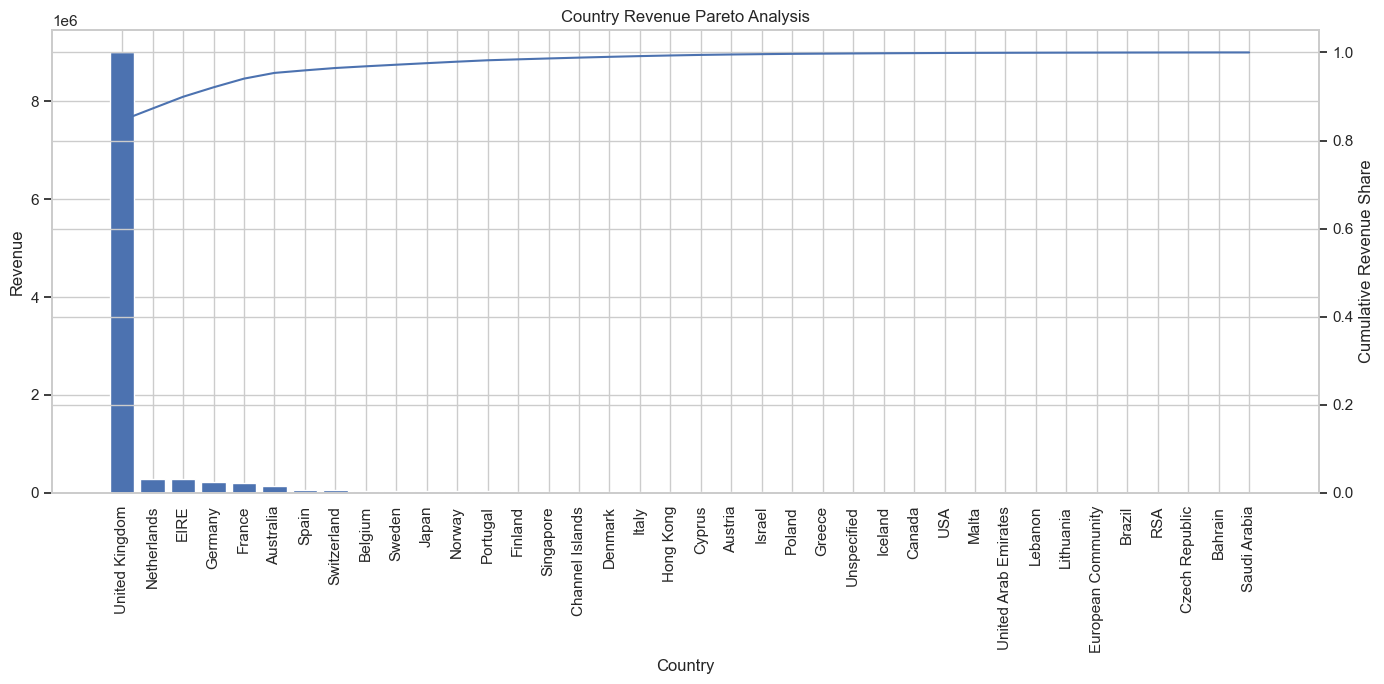

In [29]:
# Country Pareto chart
# Pareto Analysis: states that 80% of results comes from 20% of causes.
country_pareto = country_summary.sort_values(
    "Revenue",
    ascending=False
).copy()

country_pareto["Cumulative_Revenue_Share"] = (
    country_pareto["Revenue"]
    .cumsum()
    / country_pareto["Revenue"].sum()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(country_pareto.index, country_pareto["Revenue"])

ax1.set_xlabel("Country")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(country_pareto.index, country_pareto["Cumulative_Revenue_Share"])

ax2.set_ylabel("Cumulative Revenue Share")
ax2.set_ylim(0, 1.05)

plt.title("Country Revenue Pareto Analysis")

plt.tight_layout()
plt.show()

In [30]:
# Time-Bases Analysis
sales_df["Year"] = sales_df["InvoiceDate"].dt.year
sales_df["Month"] = sales_df["InvoiceDate"].dt.month
sales_df["Month_Name"] = sales_df["InvoiceDate"].dt.month_name()
sales_df["Day_of_Week"] = sales_df["InvoiceDate"].dt.day_name()
sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour

In [31]:
sales_df[
    [
        "InvoiceDate",
        "Year",
        "Month",
        "Month_Name",
        "Day_of_Week",
        "Hour"
    ]
].head()

,InvoiceDate,Year,Month,Month_Name,Day_of_Week,Hour
0,2010-12-01 08:26:00,2010,12,December,Wednesday,8
1,2010-12-01 08:26:00,2010,12,December,Wednesday,8
2,2010-12-01 08:26:00,2010,12,December,Wednesday,8
3,2010-12-01 08:26:00,2010,12,December,Wednesday,8
4,2010-12-01 08:26:00,2010,12,December,Wednesday,8


In [32]:
# Sales by day of week
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = sales_df.groupby("Day_of_Week")["Sales"].sum().reindex(weekday_order)
weekday_sales

Day_of_Week
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Saturday             NaN
Sunday        806790.781
Name: Sales, dtype: float64

- Saturday has no recorded transactions in the dataset, so Saturday sales are unavailable rather than observed as zero.

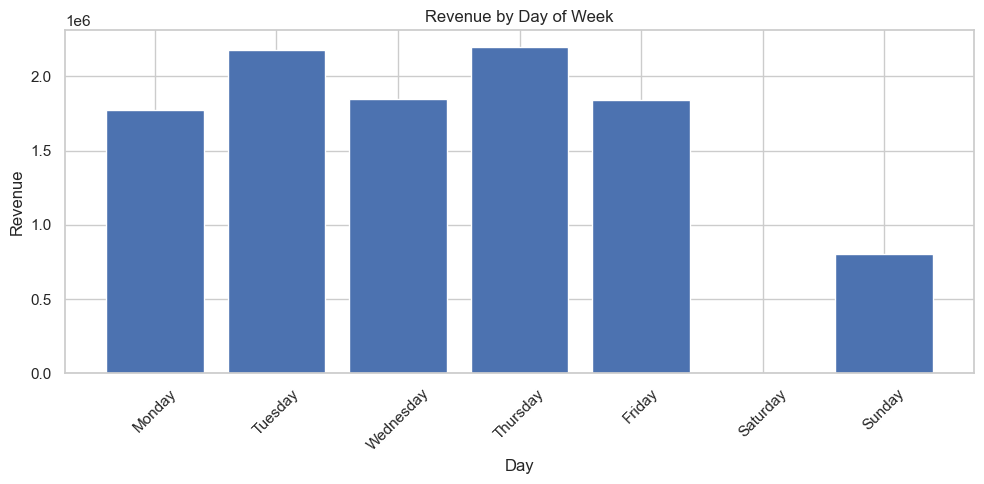

In [33]:
plt.figure(figsize=(10, 5))

plt.bar(weekday_sales.index, weekday_sales.values)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
# Transactions by day of week
weekday_transactions = sales_df.groupby("Day_of_Week")["InvoiceNo"].nunique().reindex(weekday_order)
weekday_transactions

Day_of_Week
Monday       3126.0
Tuesday      3556.0
Wednesday    3690.0
Thursday     4246.0
Friday       3140.0
Saturday        NaN
Sunday       2204.0
Name: InvoiceNo, dtype: float64

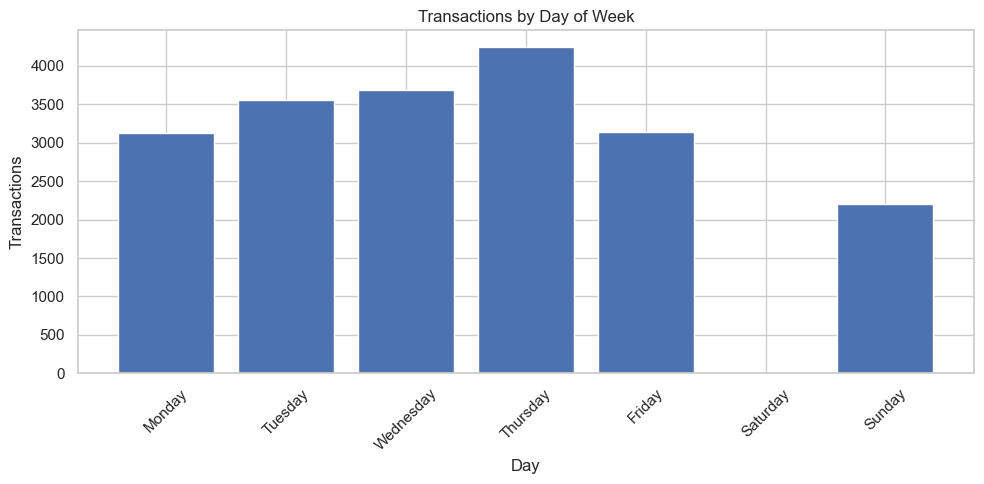

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(weekday_transactions.index, weekday_transactions.values)

plt.title("Transactions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
# Revenue by hour
hourly_sales = sales_df.groupby("Hour")["Sales"].sum()
hourly_sales.sort_values(ascending=False).head()

Hour
10    1444814.771
12    1439324.660
15    1350333.310
13    1261195.200
11    1236573.290
Name: Sales, dtype: float64

- Sales revenue is concentrated in certain hours, with 10:00 being the highest-revenue hour in the observed dataset.

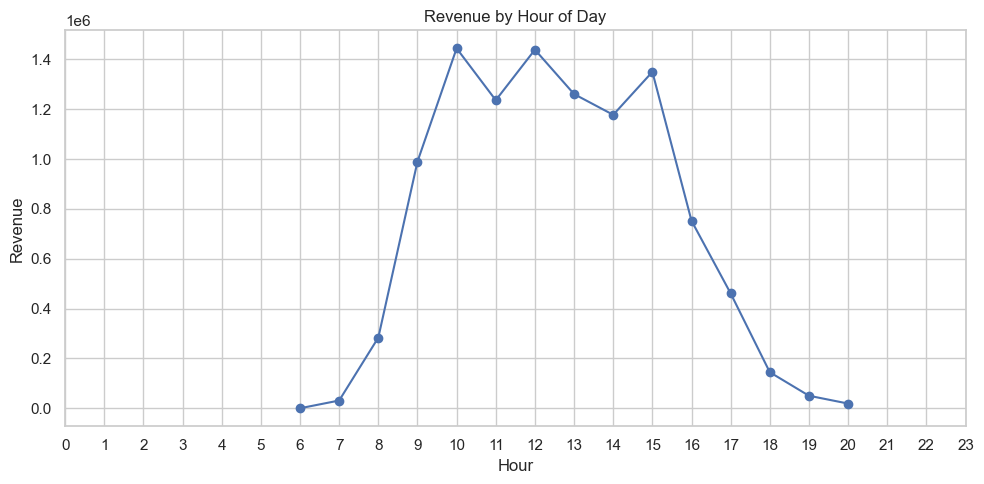

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_sales.index, hourly_sales.values, marker="o")

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [38]:
# Revenue vs Transactions
monthly_analysis = (
    sales_df
    .set_index("InvoiceDate")
    .resample("ME")
    .agg(
        Revenue=("Sales", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Customers=("CustomerID", "nunique")
    )
)

monthly_analysis["Average_Transaction_Value"] = np.round(
    monthly_analysis["Revenue"]
    / monthly_analysis["Transactions"]
,2)

monthly_analysis.head()

,Revenue,Transactions,Units,Customers,Average_Transaction_Value
InvoiceDate,,,,,
2010-12-31,821452.730,1559,358019,885,526.91
2011-01-31,689811.610,1086,387099,741,635.19
2011-02-28,522545.560,1100,282934,758,475.04
2011-03-31,716215.260,1454,376599,974,492.58
2011-04-30,536968.491,1246,307953,856,430.95


In [39]:
# Month-over-month growth
monthly_analysis["Revenue_Growth"] = monthly_analysis["Revenue"].pct_change()

monthly_analysis["Transaction_Growth"] = monthly_analysis["Transactions"].pct_change()

monthly_analysis["ATV_Growth"] = monthly_analysis["Average_Transaction_Value"].pct_change()

monthly_analysis.round(3).head()

,Revenue,Transactions,Units,Customers,Average_Transaction_Value,Revenue_Growth,Transaction_Growth,ATV_Growth
InvoiceDate,,,,,,,,
2010-12-31,821452.730,1559,358019,885,526.91,NaN,NaN,NaN
2011-01-31,689811.610,1086,387099,741,635.19,-0.160,-0.303,0.205
2011-02-28,522545.560,1100,282934,758,475.04,-0.242,0.013,-0.252
2011-03-31,716215.260,1454,376599,974,492.58,0.371,0.322,0.037
2011-04-30,536968.491,1246,307953,856,430.95,-0.250,-0.143,-0.125


In [40]:
monthly_analysis.tail(3)

,Revenue,Transactions,Units,Customers,Average_Transaction_Value,Revenue_Growth,Transaction_Growth,ATV_Growth
InvoiceDate,,,,,,,,
2011-10-31,1151263.73,2040,621029,1364,564.34,0.089763,0.109902,-0.018146
2011-11-30,1503866.78,2769,751377,1664,543.11,0.306275,0.357353,-0.037619
2011-12-31,637790.33,819,313612,615,778.74,-0.575900,-0.704225,0.433853


In [41]:
# Investigate the final month : chart has that dramatic final drop.
print("Last transaction:", sales_df["InvoiceDate"].max())
print("First transaction:", sales_df["InvoiceDate"].min())

last_month = sales_df["InvoiceDate"].max().to_period("M")

last_month_data = sales_df[sales_df["InvoiceDate"].dt.to_period("M") == last_month]

print("\nTransactions in final month:", last_month_data["InvoiceNo"].nunique())
print("Days represented in final month:", last_month_data["InvoiceDate"].dt.date.nunique())

Last transaction: 2011-12-09 12:50:00
First transaction: 2010-12-01 08:26:00

Transactions in final month: 819
Days represented in final month: 8


- The dataset does not contain the entire month of December 2011, it ends on December 9, 2011.

- So the December value in the monthly revenue chart represents only the first 8 days of December i.e. we cannot interpret that as a genuine December sales decline.